In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcdefaults()  # reset to matplotlib defaults first
plt.rcParams.update({
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'legend.frameon':    False,
    'figure.dpi':        150,
})

COLORS = {
    'synthetic': '#2166ac',
    'lightbox':  "#4f0942",
    'sunlamp':   '#d6604d',
}


In [16]:
LABELS = {
    'synthetic': 'Synthetic (validation)',
    'lightbox':  'Lightbox HIL',
    'sunlamp':   'Sunlamp HIL',
}

DOMAINS = ['synthetic', 'lightbox', 'sunlamp']

PROJECT_ROOT = Path("..").resolve()
MAT_ROOT     = PROJECT_ROOT / "spnv2/tools/outputs/efficientdet_d3/full_config"
RESULTS_DIR  = PROJECT_ROOT / 'results'
FIGURES_DIR  = PROJECT_ROOT / 'figures'

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [17]:
from scipy.io import loadmat
import numpy as np

mat_path = MAT_ROOT / "lightbox" / "per_sample_performance.mat"
mat = loadmat(str(mat_path))

mat = loadmat(mat_path)

for k, v in mat.items():
    if not k.startswith('_'):
        arr = np.array(v)
        print(f"  {k}: shape={arr.shape}, mean={arr.mean():.4f}")

  heat_eR: shape=(1, 6737), mean=6.4419
  heat_eT: shape=(1, 6737), mean=0.1736
  heat_eR_HIL: shape=(1, 6737), mean=0.1124
  heat_eT_norm_HIL: shape=(1, 6737), mean=0.0276
  heat_pose: shape=(1, 6737), mean=0.1400
  effi_iou: shape=(1, 6740), mean=0.8755
  effi_eR: shape=(1, 6740), mean=8.0040
  effi_eT: shape=(1, 6740), mean=0.1752
  effi_eR_HIL: shape=(1, 6740), mean=0.1397
  effi_eT_norm_HIL: shape=(1, 6740), mean=0.0291
  effi_pose: shape=(1, 6740), mean=0.1688
  final_pose: shape=(0, 0), mean=nan
  h_reject: shape=(1, 6740), mean=0.0004


/var/folders/fx/vmk8djws60n1_sfh07nb74080000gn/T/ipykernel_24161/3688404151.py:12: RuntimeWarning: Mean of empty slice
  print(f"  {k}: shape={arr.shape}, mean={arr.mean():.4f}")
/Users/lundeencahilly/Desktop/github/cs229-pose-estimator-confidence-prediction/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Load the full per-image error splits (NEW_DATA) — same source as the
# component plots below, so the whole notebook is on one consistent dataset.
data = {}
for domain in DOMAINS:
    path = RESULTS_DIR / f'per_image_errors_{domain}.csv'
    if not path.exists():
        print(f"Missing: {path}")
    else:
        data[domain] = pd.read_csv(path)
        print(f"{domain:12s}: {len(data[domain]):,} images | "
              f"mean E_pose={data[domain]['speed_score'].mean():.3f} | "
              f"mean E_T={data[domain]['E_T'].mean():.3f}m | "
              f"mean E_R={data[domain]['E_R'].mean():.1f}°")


ValueError: max() arg is an empty sequence

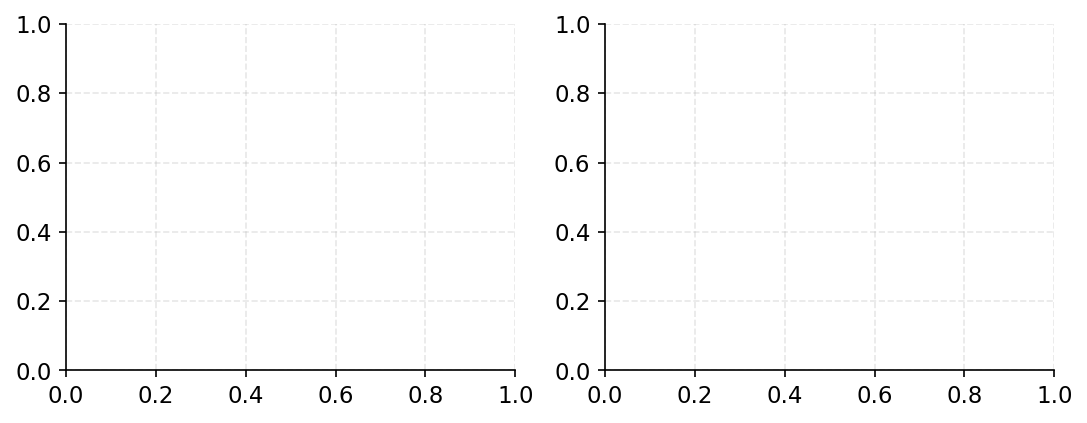

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3))

cap = max(np.percentile(data[d]['speed_score'], 90) for d in DOMAINS if d in data)

for domain in DOMAINS:
    if domain not in data:
        continue
    vals = data[domain]['speed_score']
    label = f"{LABELS[domain]}  (mean={vals.mean():.3f})"

    # Left: full distribution
    ax1.hist(vals.clip(0, 1.5), bins=60, range=(0, 1.5),
             color=COLORS[domain], alpha=0.55, label=label,
             density=True, edgecolor='none')
    ax1.axvline(vals.mean(), color=COLORS[domain], linestyle='--', linewidth=1.5)

    # Right: zoomed, top-10% tail removed
    inliers = vals[vals <= cap]
    ax2.hist(inliers, bins=60, range=(0, cap),
             color=COLORS[domain], alpha=0.55, label=label,
             density=True, edgecolor='none')
    ax2.axvline(vals.mean(), color=COLORS[domain], linestyle='--', linewidth=1.5)

ax1.set_xlabel('Pose Estimation Error SPEED Score')
ax1.set_ylabel('Density')
ax1.set_title('Full Distribution')
ax1.legend(fontsize=9)

ax2.set_xlim(0, cap)
ax2.set_xlabel('Pose Estimation Error SPEED Score')
ax2.set_ylabel('Density')
ax2.set_title('Zoomed (Top 10% of Error Tail Removed)')
ax2.legend(fontsize=9)

fig.suptitle('SPNv2 Pose Error Distribution Across Domains', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pose_error_dist.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'pose_error_dist.png', bbox_inches='tight')
plt.show()


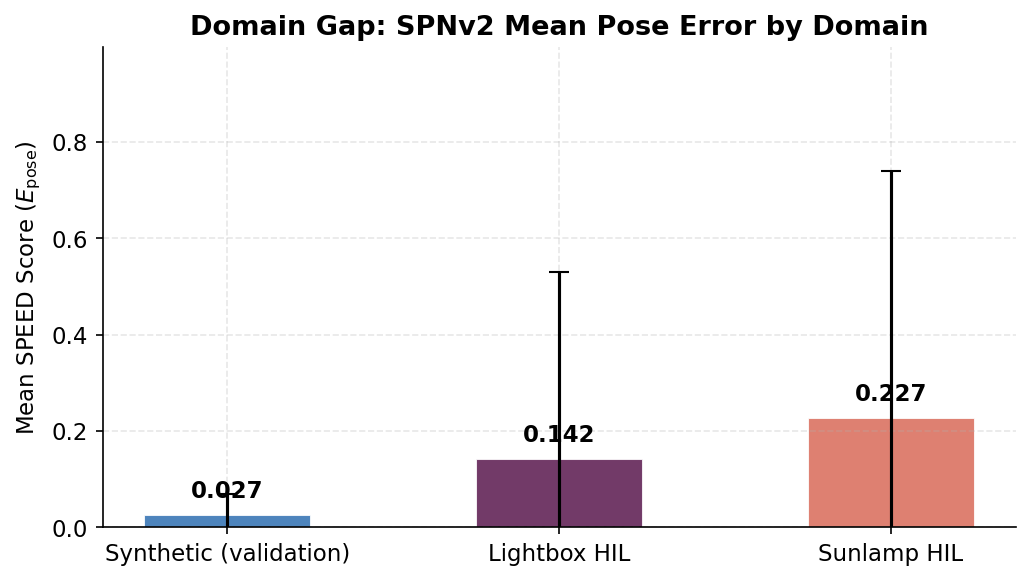

In [ ]:
# ── Figure 3: Domain Gap Summary Bar Chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

domain_list = [d for d in DOMAINS if d in data]
means  = [data[d]['speed_score'].mean() for d in domain_list]
stds   = [data[d]['speed_score'].std()  for d in domain_list]
colors = [COLORS[d] for d in domain_list]
xlabels = [LABELS[d] for d in domain_list]

bars = ax.bar(xlabels, means, color=colors, alpha=0.8,
              edgecolor='white', linewidth=0.5, width=0.5)
ax.errorbar(xlabels, means, yerr=stds,
            fmt='none', color='black', capsize=5, linewidth=1.5)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(stds) * 0.05,
            f'{mean:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('Mean SPEED Score ($E_{\\mathrm{pose}}$)')
ax.set_title('Domain Gap: SPNv2 Mean Pose Error by Domain',
             fontweight='bold')
ax.set_ylim(0, max(means) + max(stds) * 1.5)

plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'domain_gap_bar.pdf', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / 'domain_gap_bar.png', bbox_inches='tight')
plt.show()
# print("Saved → figures/domain_gap_bar.pdf")

## Pose error separated into translation and rotation

The SPEED score above blends translation and rotation into one number. Here we
remake the domain-gap figure with the two components shown **separately**
(`E_T` in metres, `E_R` in degrees), using the full `NEW_DATA` splits. Both
components are heavy-tailed (rotation runs up to ~180° from symmetry flips), so
the x-axis is clipped to the bulk for readability; the dashed line marks each
domain's **median**.

In [ ]:
# ── Translation vs. Rotation Error Distributions (separated) ──────────────────
# Remake of the milestone domain-gap figure, split into the two pose-error
# components instead of the blended SPEED score. Uses the full splits
err = {d: pd.read_csv(RESULTS_DIR / f'per_image_errors_{d}.csv') for d in DOMAINS}

COMP_LABELS = {'E_T': 'Translation Error  [m]', 'E_R': 'Rotation Error  [deg]'}


def plot_error_components(caps, fname, title):
    """One panel per component; values past caps[comp] are excluded (not piled
    at the edge). Legend reports median, mean, and % of images beyond the axis."""
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
    for ax, comp in zip(axes, COMP_LABELS):
        label, cap = COMP_LABELS[comp], caps[comp]
        for domain in DOMAINS:
            vals = err[domain][comp].values
            med, mean = np.median(vals), vals.mean()
            beyond = (vals > cap).mean() * 100
            ax.hist(vals, bins=60, range=(0, cap),
                    color=COLORS[domain], alpha=0.5, density=True, edgecolor='none',
                    label=f"{LABELS[domain]}  (median={med:.2f}, mean={mean:.2f}, {beyond:.0f}% > axis)")
            ax.axvline(med, color=COLORS[domain], ls='--', lw=1.4)
        ax.set_xlim(0, cap)
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
        ax.set_title(label.split('  ')[0])
        ax.legend(fontsize=7.5)
    fig.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{fname}.pdf', bbox_inches='tight')
    plt.savefig(FIGURES_DIR / f'{fname}.png', bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}.(pdf|png)')


# Full bulk view (fixed caps).
plot_error_components(
    {'E_T': 0.60, 'E_R': 25.0},
    'pose_error_dist_components',
    'SPNv2 Pose Error by Component Across Domains  (bulk shown; dashed = median)')

# Zoomed view: drop the top 10% tail, using the largest per-domain 90th
# percentile as the shared cap (same convention as the SPEED-score figure above).
zoom_caps = {c: max(np.percentile(err[d][c].values, 90) for d in DOMAINS) for c in COMP_LABELS}
plot_error_components(
    zoom_caps,
    'pose_error_dist_components_zoom',
    'SPNv2 Pose Error by Component  (zoomed: top 10% tail removed; dashed = median)')
